In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [4]:
google_file   = r"F:\SEM-7\Time Series Analysis\Project\Data\google_data.csv"
yfinance_file = r"F:\SEM-7\Time Series Analysis\Project\Data\tsm_yfinance_data.csv"

google   = pd.read_csv(google_file)
yfinance = pd.read_csv(yfinance_file)

print("GOOGLE FINANCE")
print(google.head())
print("\nShape:", google.shape)

print("\nYAHOO FINANCE")
print(yfinance.head())
print("\nShape:", yfinance.shape)

GOOGLE FINANCE
                  Date  Open  High   Low  Close   Volume
0      8/10/1997 16:00  5.49  5.51  5.22   5.49  2579124
1      9/10/1997 16:00  5.59  6.49  5.58   6.26  2167736
2     10/10/1997 16:00  6.94  6.97  6.29   6.55  2267033
3  13/10/1997 16:00:00  6.56  6.56  6.37   6.40   647081
4  14/10/1997 16:00:00  6.35  6.36  5.97   6.14   541983

Shape: (7273, 6)

YAHOO FINANCE
         Date      Open      High       Low     Close  Adj Close    Volume
0   10/9/1997  5.646040  6.562691  5.646040  6.323565   3.122905  10201979
1  10/10/1997  7.014374  7.040944  6.363419  6.615830   3.267240  10669148
2  10/13/1997  6.629115  6.629115  6.443128  6.469698   3.195073   3044363
3  10/14/1997  6.416558  6.429843  6.031299  6.204002   3.063857   2549907
4  10/15/1997  5.818742  6.044584  5.805458  6.031299   2.978568   3167153

Shape: (7274, 7)


In [5]:
print("GOOGLE COLUMNS:")
print(google.columns.tolist())
print("\nGOOGLE DATA TYPES:")
print(google.dtypes)
print("\n" + "="*50)
print("YAHOO COLUMNS:")
print(yfinance.columns.tolist())
print("\nYAHOO DATA TYPES:")
print(yfinance.dtypes)

GOOGLE COLUMNS:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

GOOGLE DATA TYPES:
Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

YAHOO COLUMNS:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

YAHOO DATA TYPES:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [6]:
# Google uses DD/MM/YYYY with a time
google["Date"] = pd.to_datetime(google["Date"],dayfirst=True,format="mixed")
# Yahoo uses MM/DD/YYYY
yfinance["Date"] = pd.to_datetime(yfinance["Date"],dayfirst=False,format="mixed")
# Remove time component
google["Date"] = google["Date"].dt.normalize()
yfinance["Date"] = yfinance["Date"].dt.normalize()
# Sort both datasets
google = google.sort_values("Date").reset_index(drop=True)
yfinance = yfinance.sort_values("Date").reset_index(drop=True)

print("GOOGLE FINANCE")
print("Records:", len(google))
print("Date range:", google["Date"].min(), "to", google["Date"].max())

print("\nYAHOO FINANCE")
print("Records:", len(yfinance))
print("Date range:", yfinance["Date"].min(), "to", yfinance["Date"].max())

GOOGLE FINANCE
Records: 7273
Date range: 1997-10-08 00:00:00 to 2026-09-10 00:00:00

YAHOO FINANCE
Records: 7274
Date range: 1997-10-09 00:00:00 to 2026-09-10 00:00:00


In [7]:
google_dates = set(google["Date"])
yahoo_dates = set(yfinance["Date"])

matching_dates = google_dates & yahoo_dates
google_only = google_dates - yahoo_dates
yahoo_only = yahoo_dates - google_dates

print("DATE COMPARISON")

print(f"Google Finance records : {len(google)}")
print(f"Yahoo Finance records  : {len(yfinance)}")
print(f"Matching dates         : {len(matching_dates)}")
print(f"Google-only dates      : {len(google_only)}")
print(f"Yahoo-only dates       : {len(yahoo_only)}")

if google_only:
    print("\nDates only in Google Finance:")
    print(sorted(google_only))

if yahoo_only:
    print("\nDates only in Yahoo Finance:")
    print(sorted(yahoo_only))

DATE COMPARISON
Google Finance records : 7273
Yahoo Finance records  : 7274
Matching dates         : 7271
Google-only dates      : 2
Yahoo-only dates       : 3

Dates only in Google Finance:
[Timestamp('1997-10-08 00:00:00'), Timestamp('2009-07-03 00:00:00')]

Dates only in Yahoo Finance:
[Timestamp('1997-11-25 00:00:00'), Timestamp('1997-12-17 00:00:00'), Timestamp('1998-01-14 00:00:00')]


In [8]:
comparison = pd.merge(google,yfinance,on="Date",how="inner",suffixes=("_Google", "_Yahoo"))
comparison = comparison.sort_values("Date").reset_index(drop=True)

print("COMMON DATA")
print("Common records:", len(comparison))
print("Start date:", comparison["Date"].min())
print("End date:", comparison["Date"].max())

print("\nColumns:")
print(comparison.columns.tolist())

print("\nFirst 5 rows:")
print(comparison.head())

COMMON DATA
Common records: 7271
Start date: 1997-10-09 00:00:00
End date: 2026-09-10 00:00:00

Columns:
['Date', 'Open_Google', 'High_Google', 'Low_Google', 'Close_Google', 'Volume_Google', 'Open_Yahoo', 'High_Yahoo', 'Low_Yahoo', 'Close_Yahoo', 'Adj Close', 'Volume_Yahoo']

First 5 rows:
        Date  Open_Google  High_Google  Low_Google  Close_Google  \
0 1997-10-09         5.59         6.49        5.58          6.26   
1 1997-10-10         6.94         6.97        6.29          6.55   
2 1997-10-13         6.56         6.56        6.37          6.40   
3 1997-10-14         6.35         6.36        5.97          6.14   
4 1997-10-15         5.76         5.98        5.74          5.97   

   Volume_Google  Open_Yahoo  High_Yahoo  Low_Yahoo  Close_Yahoo  Adj Close  \
0        2167736    5.646040    6.562691   5.646040     6.323565   3.122905   
1        2267033    7.014374    7.040944   6.363419     6.615830   3.267240   
2         647081    6.629115    6.629115   6.443128     6.46969

In [9]:
print("GOOGLE FINANCE COLUMNS:")
print(google.columns.tolist())

print("\nYAHOO FINANCE COLUMNS:")
print(yfinance.columns.tolist())

print("\nCOMMON DATA SAMPLE:")
print(comparison[["Date","Open_Google","High_Google","Low_Google","Close_Google","Open_Yahoo","High_Yahoo","Low_Yahoo","Close_Yahoo"]].head(10))

GOOGLE FINANCE COLUMNS:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

YAHOO FINANCE COLUMNS:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

COMMON DATA SAMPLE:
        Date  Open_Google  High_Google  Low_Google  Close_Google  Open_Yahoo  \
0 1997-10-09         5.59         6.49        5.58          6.26    5.646040   
1 1997-10-10         6.94         6.97        6.29          6.55    7.014374   
2 1997-10-13         6.56         6.56        6.37          6.40    6.629115   
3 1997-10-14         6.35         6.36        5.97          6.14    6.416558   
4 1997-10-15         5.76         5.98        5.74          5.97    5.818742   
5 1997-10-16         5.97         5.97        5.76          5.78    6.031299   
6 1997-10-17         5.52         5.53        5.27          5.28    5.579616   
7 1997-10-20         4.42         4.73        4.40          4.63    4.463693   
8 1997-10-21         4.84         5.28        4.81          5.28    4.888806   
9 1997-10-22    

In [10]:
# Calculate absolute and percentage differences
for col in ["Open", "High", "Low", "Close"]:
    
    comparison[f"{col}_Difference"] = (comparison[f"{col}_Google"] - comparison[f"{col}_Yahoo"])
    comparison[f"{col}_Abs_Difference"] = (comparison[f"{col}_Difference"].abs())
    comparison[f"{col}_Percent_Difference"] = (comparison[f"{col}_Abs_Difference"] / comparison[f"{col}_Yahoo"]) * 100

print("Difference columns created successfully.")
print(comparison[["Date","Close_Google","Close_Yahoo","Close_Difference","Close_Percent_Difference"]].head(10))

Difference columns created successfully.
        Date  Close_Google  Close_Yahoo  Close_Difference  \
0 1997-10-09          6.26     6.323565         -0.063565   
1 1997-10-10          6.55     6.615830         -0.065830   
2 1997-10-13          6.40     6.469698         -0.069698   
3 1997-10-14          6.14     6.204002         -0.064002   
4 1997-10-15          5.97     6.031299         -0.061299   
5 1997-10-16          5.78     5.845312         -0.065312   
6 1997-10-17          5.28     5.340490         -0.060490   
7 1997-10-20          4.63     4.676250         -0.046250   
8 1997-10-21          5.28     5.340490         -0.060490   
9 1997-10-22          4.67     4.716104         -0.046104   

   Close_Percent_Difference  
0                  1.005208  
1                  0.995037  
2                  1.077298  
3                  1.031623  
4                  1.016350  
5                  1.117342  
6                  1.132665  
7                  0.989040  
8                

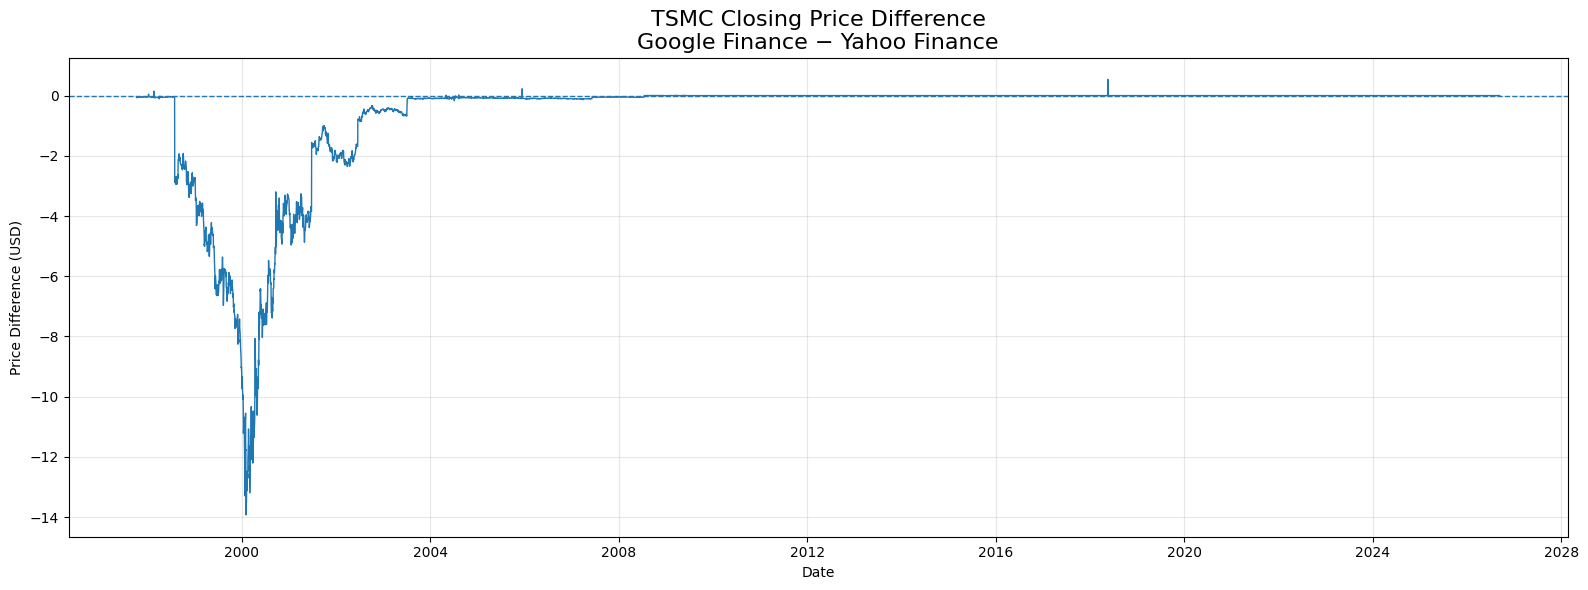

In [11]:
plt.figure(figsize=(16,6))
plt.plot(comparison["Date"],comparison["Close_Difference"],linewidth=1)
plt.axhline(0,linestyle="--",linewidth=1)
plt.title("TSMC Closing Price Difference\n""Google Finance − Yahoo Finance",fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price Difference (USD)")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

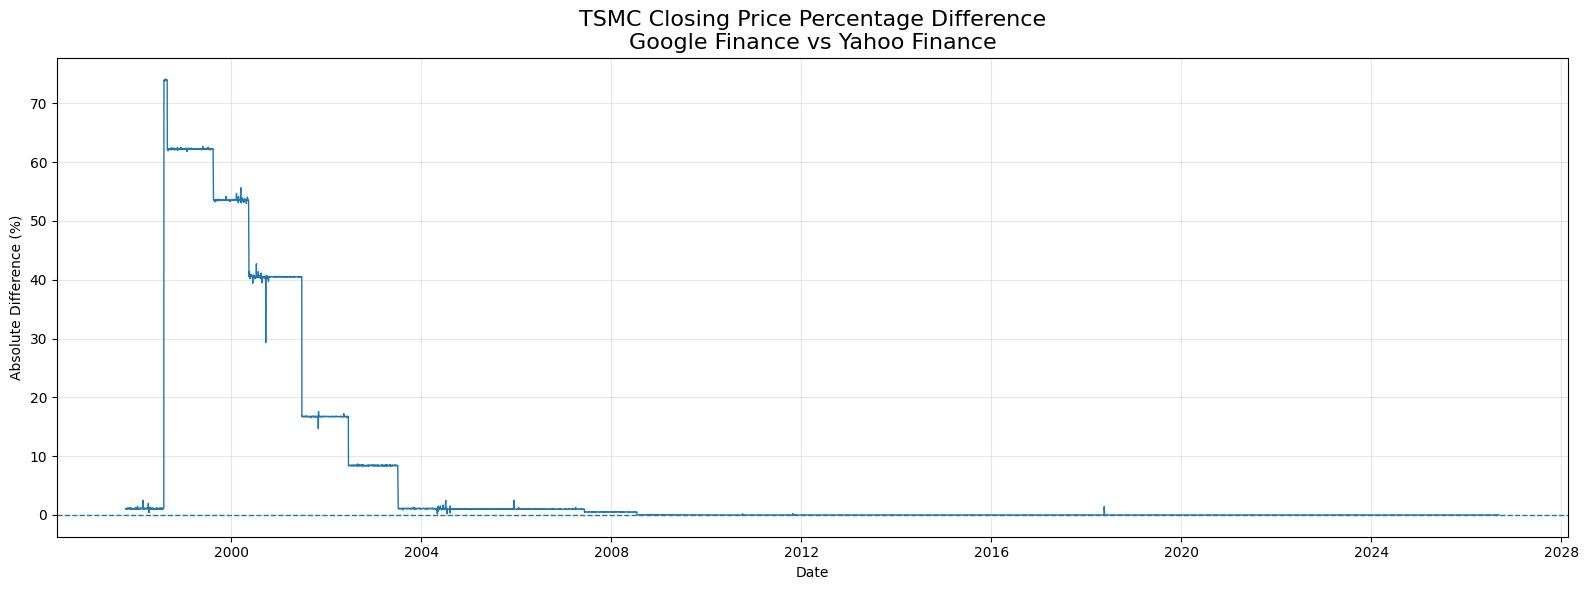

In [12]:
plt.figure(figsize=(16,6))
plt.plot(comparison["Date"],comparison["Close_Percent_Difference"],linewidth=1)
plt.axhline(0,linestyle="--",linewidth=1)
plt.title("TSMC Closing Price Percentage Difference\n""Google Finance vs Yahoo Finance",fontsize=16)
plt.xlabel("Date")
plt.ylabel("Absolute Difference (%)")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
largest_differences = (comparison[["Date","Close_Google","Close_Yahoo","Close_Difference","Close_Percent_Difference"]].sort_values("Close_Percent_Difference",ascending=False).head(20))

print("20 DATES WITH THE LARGEST CLOSING-PRICE DIFFERENCES")
print("=" * 70)
print(largest_differences.to_string(index=False))

20 DATES WITH THE LARGEST CLOSING-PRICE DIFFERENCES
      Date  Close_Google  Close_Yahoo  Close_Difference  Close_Percent_Difference
1998-08-11          0.94     3.626750         -2.686750                 74.081478
1998-08-18          1.03     3.972155         -2.942155                 74.069492
1998-08-07          1.03     3.972155         -2.942155                 74.069492
1998-08-14          1.03     3.972155         -2.942155                 74.069492
1998-08-17          1.03     3.972155         -2.942155                 74.069492
1998-08-12          1.00     3.852592         -2.852592                 74.043449
1998-08-13          0.99     3.812738         -2.822738                 74.034407
1998-08-10          0.98     3.772883         -2.792883                 74.025168
1998-08-04          0.97     3.733029         -2.763029                 74.015738
1998-08-21          0.96     3.693174         -2.733174                 74.006098
1998-08-05          0.98     3.759598         

In [14]:
comparison["Close_Ratio"] = (comparison["Close_Yahoo"]/comparison["Close_Google"])
comparison["Close_Difference_Percent"] = ((comparison["Close_Yahoo"] - comparison["Close_Google"])/comparison["Close_Google"])*100

print(comparison[["Date","Close_Google","Close_Yahoo","Close_Ratio","Close_Difference_Percent"]].head(20).to_string(index=False))

periods = [("1997-10-01", "1999-12-31"),
           ("2000-01-01", "2004-12-31"),
           ("2005-01-01", "2009-12-31"),
           ("2010-01-01", "2019-12-31"),
           ("2020-01-01", "2026-09-10")]

for start, end in periods:
    period = comparison[(comparison["Date"] >= start) & (comparison["Date"] <= end)]
    
    print("\n" + "=" * 60)
    print(f"{start} → {end}")
    print("=" * 60)
    
    print(f"Records: {len(period)}")
    print(
        f"Mean difference: "
        f"{period['Close_Difference_Percent'].mean():.4f}%")
    print(
        f"Median difference: "
        f"{period['Close_Difference_Percent'].median():.4f}%")
    print(
        f"Minimum difference: "
        f"{period['Close_Difference_Percent'].min():.4f}%")
    print(
        f"Maximum difference: "
        f"{period['Close_Difference_Percent'].max():.4f}%")

      Date  Close_Google  Close_Yahoo  Close_Ratio  Close_Difference_Percent
1997-10-09          6.26     6.323565     1.010154                  1.015415
1997-10-10          6.55     6.615830     1.010050                  1.005037
1997-10-13          6.40     6.469698     1.010890                  1.089030
1997-10-14          6.14     6.204002     1.010424                  1.042376
1997-10-15          5.97     6.031299     1.010268                  1.026786
1997-10-16          5.78     5.845312     1.011300                  1.129967
1997-10-17          5.28     5.340490     1.011456                  1.145641
1997-10-20          4.63     4.676250     1.009989                  0.998920
1997-10-21          5.28     5.340490     1.011456                  1.145641
1997-10-22          4.67     4.716104     1.009872                  0.987238
1997-10-23          4.39     4.437123     1.010734                  1.073413
1997-10-24          4.15     4.197997     1.011566                  1.156556

In [15]:
# Print the two closing-price series side by side
series = comparison[["Date","Close_Google","Close_Yahoo"]].copy()

print("=" * 70)
print("TSMC CLOSING PRICE SERIES")
print("=" * 70)

print("\nFirst 20 records:")
print(series.head(20).to_string(index=False))

print("\nLast 20 records:")
print(series.tail(20).to_string(index=False))

print("\nTotal common records:", len(series))

TSMC CLOSING PRICE SERIES

First 20 records:
      Date  Close_Google  Close_Yahoo
1997-10-09          6.26     6.323565
1997-10-10          6.55     6.615830
1997-10-13          6.40     6.469698
1997-10-14          6.14     6.204002
1997-10-15          5.97     6.031299
1997-10-16          5.78     5.845312
1997-10-17          5.28     5.340490
1997-10-20          4.63     4.676250
1997-10-21          5.28     5.340490
1997-10-22          4.67     4.716104
1997-10-23          4.39     4.437123
1997-10-24          4.15     4.197997
1997-10-27          3.60     3.640035
1997-10-28          4.42     4.463693
1997-10-29          4.01     4.051864
1997-10-30          3.90     3.945586
1997-10-31          4.15     4.197997
1997-11-03          4.77     4.822382
1997-11-04          4.77     4.822382
1997-11-05          5.15     5.207642

Last 20 records:
      Date  Close_Google  Close_Yahoo
2026-08-13        430.49   430.489990
2026-08-14        426.35   426.350006
2026-08-17        430.97 

In [ ]:
fig = go.Figure()
# CLOSE

fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["Close_Google"],mode="lines",name="Google Finance",
                         visible=True,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Google Close: $%{y:.4f}<extra></extra>"))

fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["Close_Yahoo"],mode="lines",name="Yahoo Finance",
                         visible=True,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Yahoo Close: $%{y:.4f}<extra></extra>"))

# OPEN
fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["Open_Google"],mode="lines",name="Google Finance",
                         visible=False,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Google Open: $%{y:.4f}<extra></extra>"))

fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["Open_Yahoo"],mode="lines",name="Yahoo Finance",
                         visible=False,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Yahoo Open: $%{y:.4f}<extra></extra>"))

# HIGH
fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["High_Google"],mode="lines",name="Google Finance",
                         visible=False,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Google High: $%{y:.4f}<extra></extra>"))

fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["High_Yahoo"],mode="lines",name="Yahoo Finance",
                         visible=False,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Yahoo High: $%{y:.4f}<extra></extra>"))

# LOW

fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["Low_Google"],mode="lines",name="Google Finance",
                         visible=False,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Google Low: $%{y:.4f}<extra></extra>"))

fig.add_trace(go.Scatter(x=comparison["Date"],y=comparison["Low_Yahoo"],mode="lines",name="Yahoo Finance",
                         visible=False,hovertemplate="Date: %{x|%Y-%m-%d}<br>""Yahoo Low: $%{y:.4f}<extra></extra>"))

# BUTTONS

buttons = [dict(label="Close",method="update",
        args=[{"visible": [True, True,False, False,False, False,False, False]},
        {"title": "TSMC (TSM) — Closing Price","yaxis": {"title": "Closing Price (USD)"}}]),

    dict(label="Open",method="update",
        args=[{"visible": [False, False,True, True,False, False,False, False]},
            {"title": "TSMC (TSM) — Opening Price","yaxis": {"title": "Opening Price (USD)"}}]),

    dict(
        label="High",
        method="update",
        args=[
            {"visible": [
                False, False,
                False, False,
                True, True,
                False, False
            ]},
            {
                "title": "TSMC (TSM) — High Price",
                "yaxis": {"title": "High Price (USD)"}
            }
        ]
    ),

    dict(
        label="Low",
        method="update",
        args=[
            {"visible": [
                False, False,
                False, False,
                False, False,
                True, True
            ]},
            {
                "title": "TSMC (TSM) — Low Price",
                "yaxis": {"title": "Low Price (USD)"}
            }
        ]
    )
]


# LAYOUT

fig.update_layout(
    # Title
    title=dict(text="TSMC (TSM) — Google Finance vs Yahoo Finance",x=0.5,xanchor="center",y=0.96),
    xaxis=dict(title="Date"),
    yaxis=dict(title="Closing Price (USD)"),
    hovermode="x unified",
    template="plotly_white",
    height=700,
    # Buttons BELOW the title
    updatemenus=[dict(type="buttons",direction="right",buttons=buttons,x=0.5,y=0.89,
                      xanchor="center",yanchor="top",showactive=True,bgcolor="white",
                      bordercolor="#b8b8b8",borderwidth=1,font=dict(size=13))],
    # More space at top for title + buttons
    margin=dict(l=80,r=40,t=100,b=70),
    legend=dict(orientation="h",yanchor="top",y=1.0,xanchor="left",x=0))

fig.show()

In [ ]:
# Create copies so original datasets remain unchanged
google_analysis = google.copy()
yahoo_analysis  = yfinance.copy()

# Sort chronologically
google_analysis = (google_analysis.sort_values("Date").reset_index(drop=True))
yahoo_analysis  = (yahoo_analysis.sort_values("Date").reset_index(drop=True))

print("FULL HISTORICAL DATA")
print("=" * 60)

print("\nGOOGLE FINANCE")
print("Rows:", len(google_analysis))
print("Date range:",google_analysis["Date"].min().date(),"to",google_analysis["Date"].max().date())

print("\nYAHOO FINANCE")
print("Rows:", len(yahoo_analysis))
print("Date range:",yahoo_analysis["Date"].min().date(),"to",yahoo_analysis["Date"].max().date())

FULL HISTORICAL DATA

GOOGLE FINANCE
Rows: 7273
Date range: 1997-10-08 to 2026-09-10

YAHOO FINANCE
Rows: 7274
Date range: 1997-10-09 to 2026-09-10


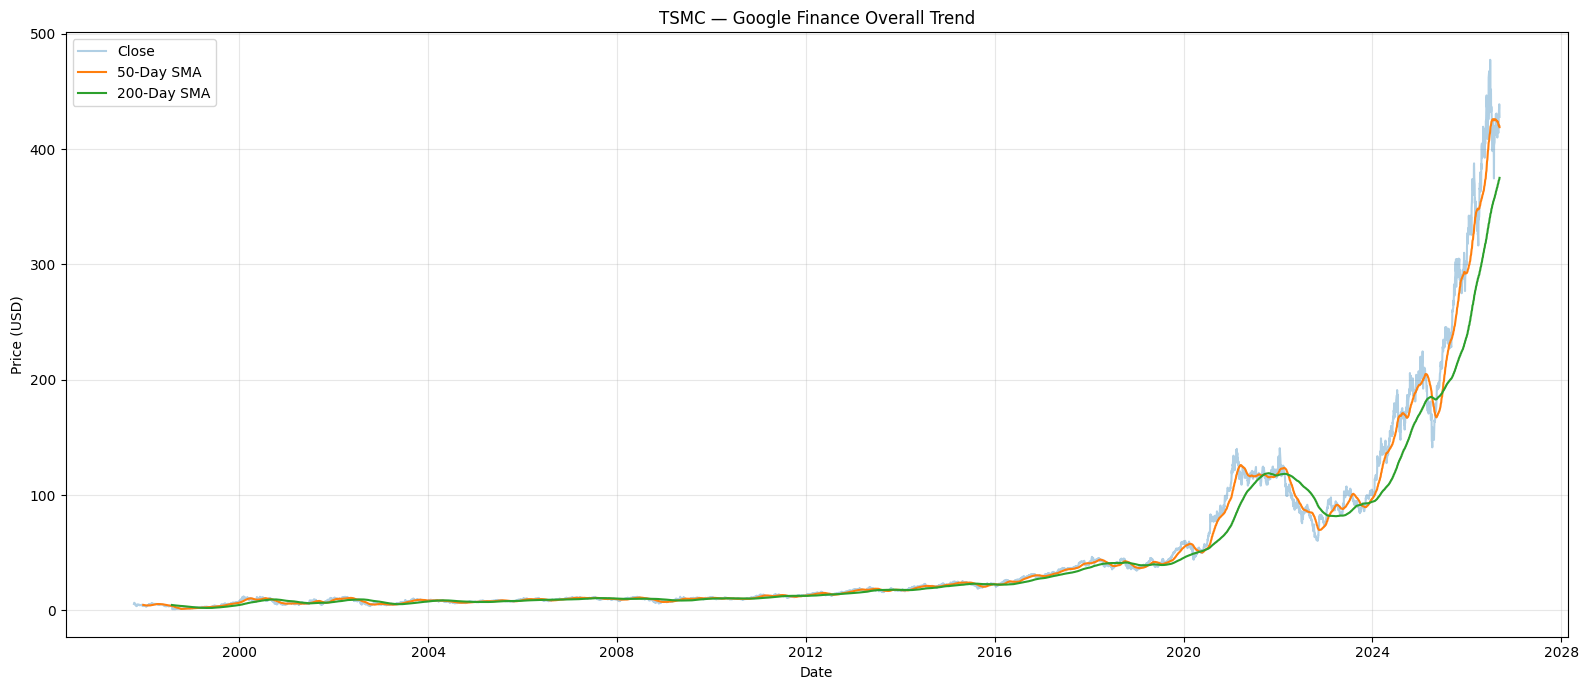

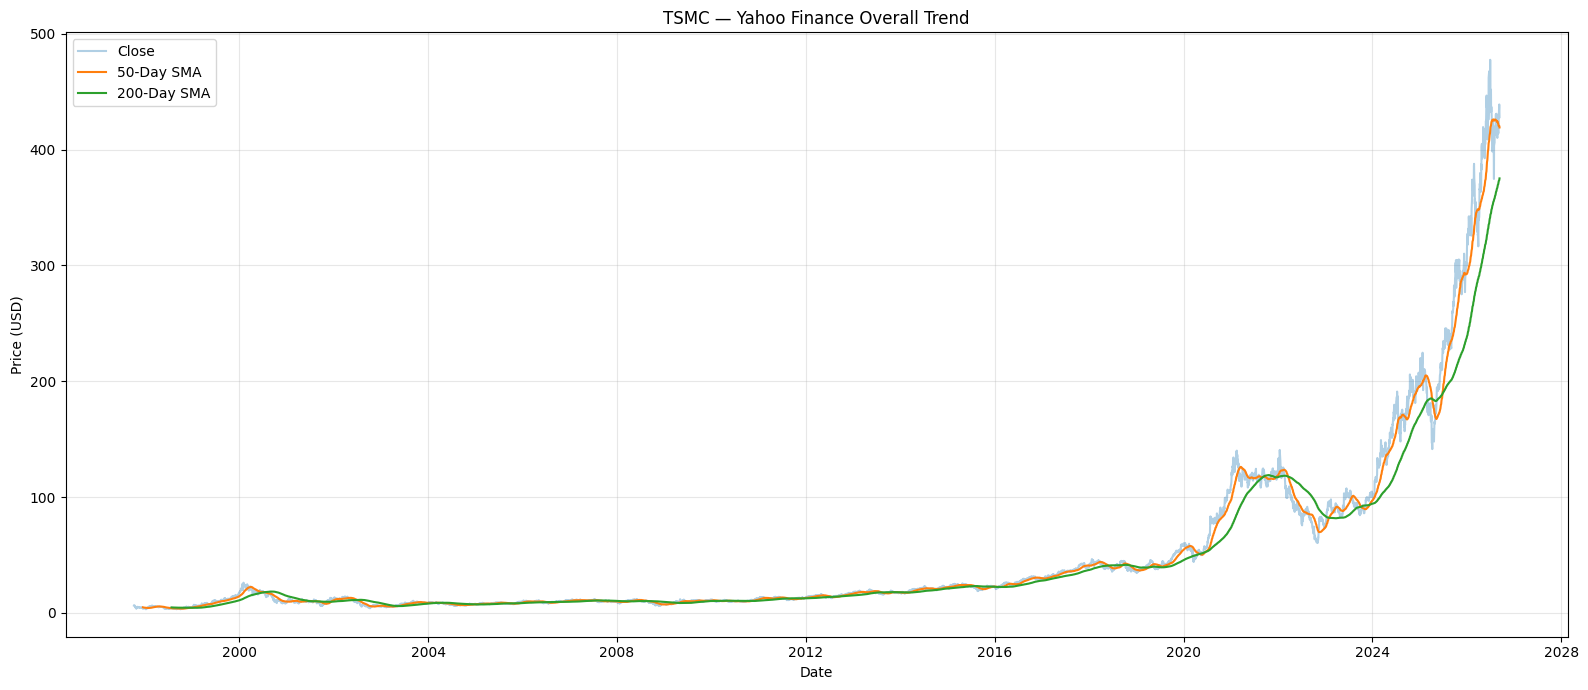

In [ ]:
# CELL 3: OVERALL TREND WITH MOVING AVERAGES

# Google
google_analysis["SMA_50"]  = (google_analysis["Close"].rolling(50).mean())
google_analysis["SMA_200"] = (google_analysis["Close"].rolling(200).mean())
# Yahoo
yahoo_analysis["SMA_50"]  = (yahoo_analysis["Close"].rolling(50).mean())
yahoo_analysis["SMA_200"] = (yahoo_analysis["Close"].rolling(200).mean())
# Google
plt.figure(figsize=(16, 7))
plt.plot(google_analysis["Date"],google_analysis["Close"],label="Close",alpha=0.35)
plt.plot(google_analysis["Date"],google_analysis["SMA_50"],label="50-Day SMA")
plt.plot(google_analysis["Date"],google_analysis["SMA_200"],label="200-Day SMA")
plt.title("TSMC — Google Finance Overall Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Yahoo
plt.figure(figsize=(16, 7))
plt.plot(yahoo_analysis["Date"],yahoo_analysis["Close"],label="Close",alpha=0.35)
plt.plot(yahoo_analysis["Date"],yahoo_analysis["SMA_50"],label="50-Day SMA")
plt.plot(yahoo_analysis["Date"],yahoo_analysis["SMA_200"],label="200-Day SMA")
plt.title("TSMC — Yahoo Finance Overall Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

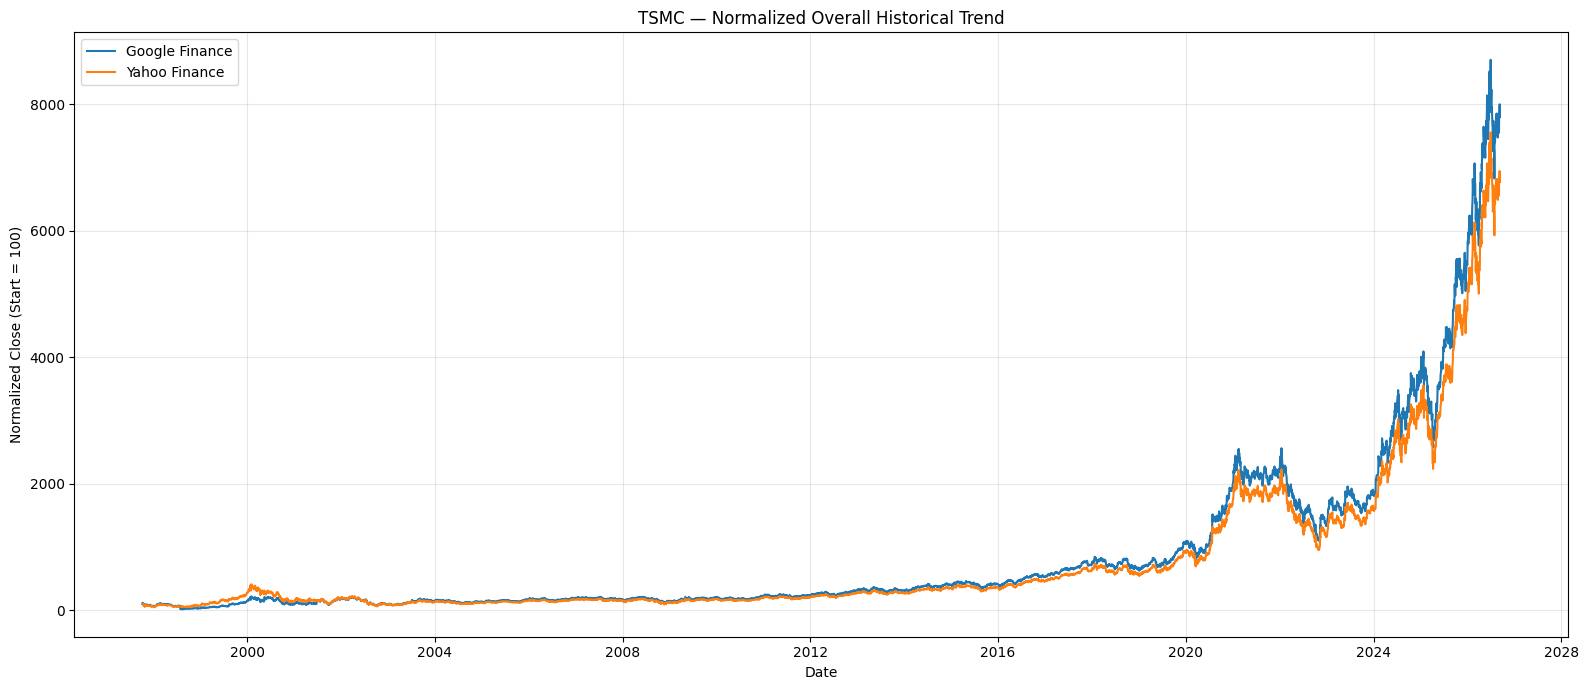

In [ ]:
# CELL 4: NORMALIZED OVERALL TREND

google_analysis["Normalized_Close"] = (google_analysis["Close"]/google_analysis["Close"].iloc[0]) * 100
yahoo_analysis["Normalized_Close"]  = (yahoo_analysis["Close"]/yahoo_analysis["Close"].iloc[0]) * 100

plt.figure(figsize=(16, 7))
plt.plot(google_analysis["Date"],google_analysis["Normalized_Close"],label="Google Finance")
plt.plot(yahoo_analysis["Date"],yahoo_analysis["Normalized_Close"],label="Yahoo Finance")
plt.title("TSMC — Normalized Overall Historical Trend")
plt.xlabel("Date")
plt.ylabel("Normalized Close (Start = 100)")
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 5: DAILY RETURNS

google_analysis["Return"] = (google_analysis["Close"].pct_change())
yahoo_analysis["Return"]  = (yahoo_analysis["Close"].pct_change())

google_returns = (google_analysis.dropna(subset=["Return"]).copy())
yahoo_returns  = (yahoo_analysis.dropna(subset=["Return"]).copy())

print("DAILY RETURNS CREATED")
print("=" * 60)

print("\nGoogle Finance observations:",len(google_returns))
print("Yahoo Finance observations:",len(yahoo_returns))

DAILY RETURNS CREATED

Google Finance observations: 7272
Yahoo Finance observations: 7273


In [ ]:
# CELL 6: WEEKLY SEASONALITY

google_returns["Day_of_Week"] = (google_returns["Date"].dt.day_name())
yahoo_returns["Day_of_Week"]  = (yahoo_returns["Date"].dt.day_name())

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday"]
google_weekday = (google_returns.groupby("Day_of_Week")["Return"].mean().reindex(day_order))
yahoo_weekday  = (yahoo_returns.groupby("Day_of_Week")["Return"].mean().reindex(day_order))

weekday_comparison = pd.DataFrame({"Google Finance": google_weekday,"Yahoo Finance": yahoo_weekday})
print("AVERAGE DAILY RETURN BY WEEKDAY")
print("=" * 60)
display(weekday_comparison)

AVERAGE DAILY RETURN BY WEEKDAY


,Google Finance,Yahoo Finance
Day_of_Week,,
Monday,-0.000590,-0.000969
Tuesday,0.002409,0.002136
Wednesday,0.002158,0.001802
Thursday,0.001330,0.001122
Friday,-0.000061,0.000501


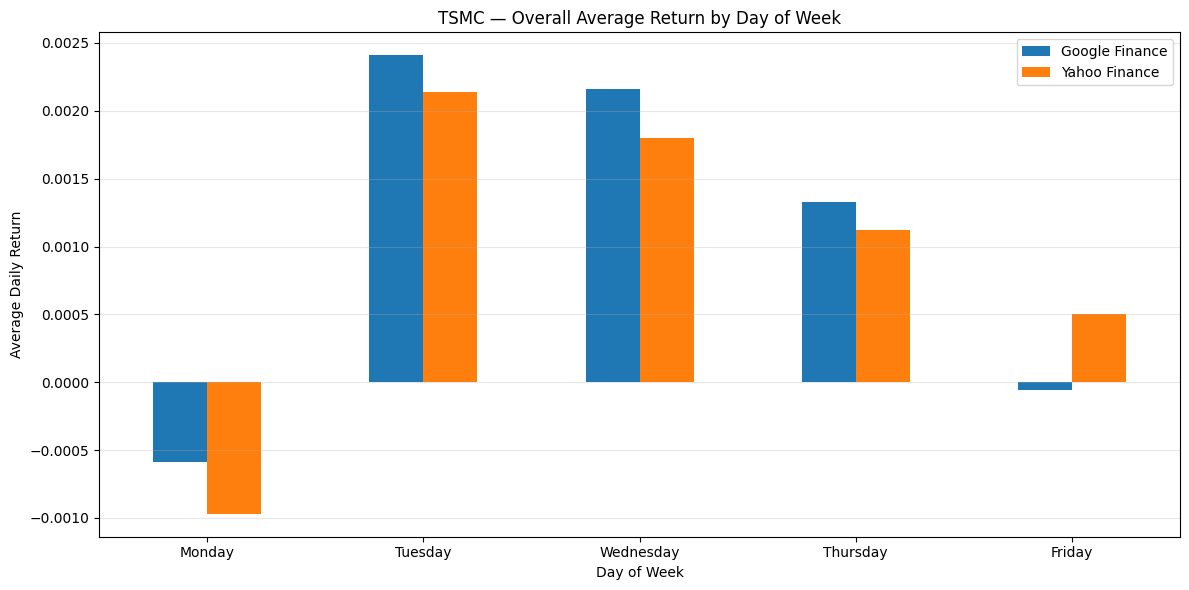

In [ ]:
# CELL 7: WEEKLY SEASONALITY PLOT
weekday_comparison.plot(kind="bar",figsize=(12, 6))
plt.title("TSMC — Overall Average Return by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Return")
plt.xticks(rotation=0)
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 8: MONTHLY SEASONALITY

google_returns["Month"] = (google_returns["Date"].dt.month)
yahoo_returns["Month"]  = (yahoo_returns["Date"].dt.month)

months = list(range(1, 13))

google_monthly = (google_returns.groupby("Month")["Return"].mean().reindex(months))
yahoo_monthly  = (yahoo_returns.groupby("Month")["Return"].mean().reindex(months))

month_names = ["Jan", "Feb", "Mar", "Apr","May", "Jun", "Jul", "Aug","Sep", "Oct", "Nov", "Dec"]
monthly_comparison = pd.DataFrame({"Google Finance":google_monthly.values,"Yahoo Finance":yahoo_monthly.values}, index=month_names)
print("AVERAGE RETURN BY MONTH")
print("=" * 60)
display(monthly_comparison)

AVERAGE RETURN BY MONTH


,Google Finance,Yahoo Finance
Jan,0.003611,0.003609
Feb,0.000521,0.000518
Mar,0.001201,0.001192
Apr,0.001243,0.001243
May,0.000647,0.000169
Jun,0.001547,0.000744
Jul,-0.001433,-0.000406
Aug,0.001219,0.000182
Sep,-0.001087,-0.001049
Oct,0.002446,0.002237


In [ ]:
# ============================================
# CELL 10: QUARTERLY SEASONALITY
# ============================================

google_returns["Quarter"] = (google_returns["Date"].dt.quarter)
yahoo_returns["Quarter"]  = (yahoo_returns["Date"].dt.quarter)

google_quarterly = (google_returns.groupby("Quarter")["Return"].mean().reindex([1, 2, 3, 4]))
yahoo_quarterly  = (yahoo_returns.groupby("Quarter")["Return"].mean().reindex([1, 2, 3, 4]))

quarterly_comparison = pd.DataFrame({"Google Finance":google_quarterly.values,"Yahoo Finance":yahoo_quarterly.values}
                                    ,index=["Q1", "Q2", "Q3", "Q4"])
print("AVERAGE RETURN BY QUARTER")
print("=" * 60)
display(quarterly_comparison)

AVERAGE RETURN BY QUARTER


,Google Finance,Yahoo Finance
Q1,0.001782,0.001779
Q2,0.001146,0.000715
Q3,-0.000396,-0.000402
Q4,0.001815,0.001741


In [26]:
# ============================================
# CELL 11: SEASONAL AUTOCORRELATION
# ============================================

from statsmodels.tsa.stattools import acf


google_acf = acf(
    google_returns["Return"],
    nlags=252,
    fft=True
)


yahoo_acf = acf(
    yahoo_returns["Return"],
    nlags=252,
    fft=True
)


seasonal_lags = [
    5,
    21,
    252
]


print("SEASONAL AUTOCORRELATION")
print("=" * 60)


for lag in seasonal_lags:

    print(f"\nLag {lag}")

    print(
        f"Google Finance : "
        f"{google_acf[lag]:.6f}"
    )

    print(
        f"Yahoo Finance  : "
        f"{yahoo_acf[lag]:.6f}"
    )

SEASONAL AUTOCORRELATION

Lag 5
Google Finance : -0.002328
Yahoo Finance  : -0.004446

Lag 21
Google Finance : -0.024291
Yahoo Finance  : -0.024266

Lag 252
Google Finance : -0.003095
Yahoo Finance  : -0.003145


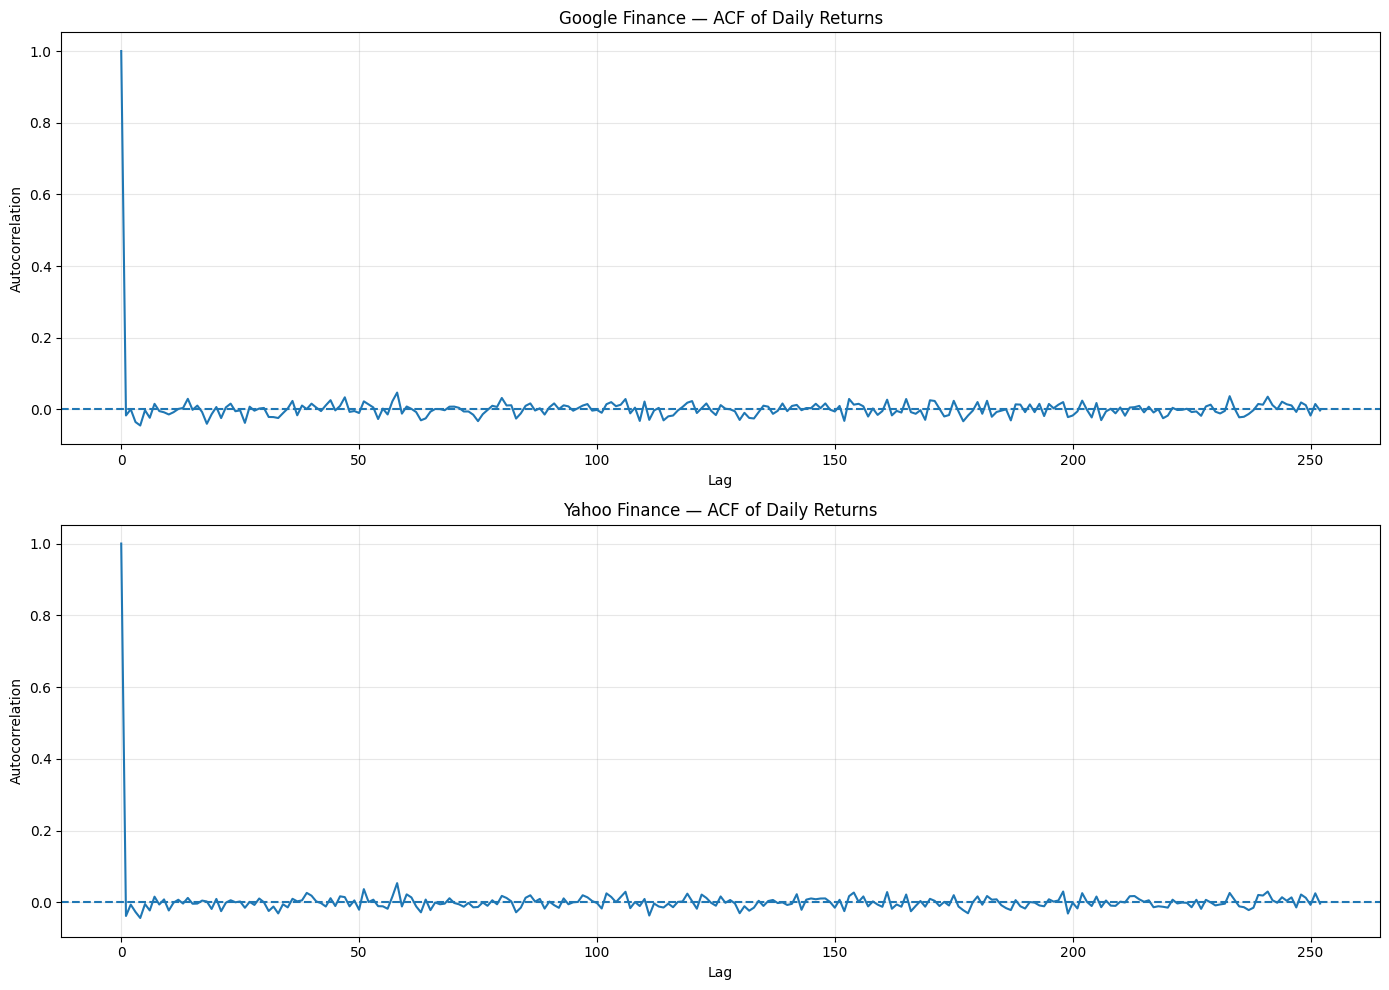

In [ ]:
# ============================================
# CELL 12: ACF PLOT
# ============================================

fig, axes = plt.subplots(2,1,figsize=(14, 10))

# Google
axes[0].plot(
    range(253),
    google_acf[:253]
)

axes[0].axhline(
    0,
    linestyle="--"
)

axes[0].set_title(
    "Google Finance — ACF of Daily Returns"
)

axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")

axes[0].grid(
    True,
    alpha=0.3
)


# Yahoo
axes[1].plot(
    range(253),
    yahoo_acf[:253]
)

axes[1].axhline(
    0,
    linestyle="--"
)

axes[1].set_title(
    "Yahoo Finance — ACF of Daily Returns"
)

axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelation")

axes[1].grid(
    True,
    alpha=0.3
)


plt.tight_layout()
plt.show()

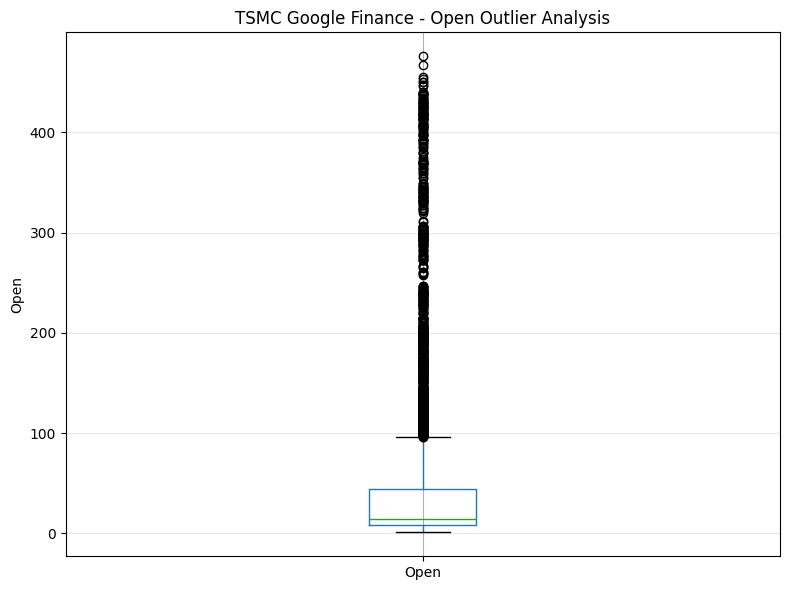

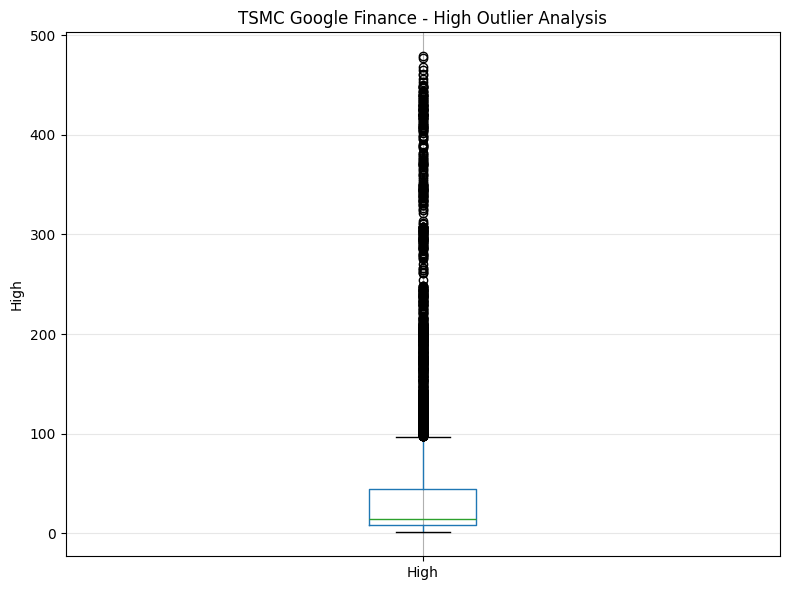

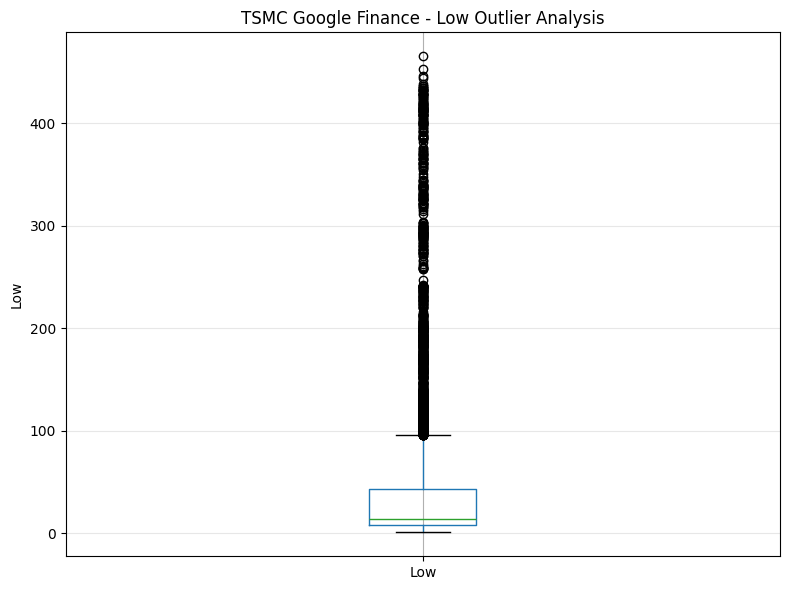

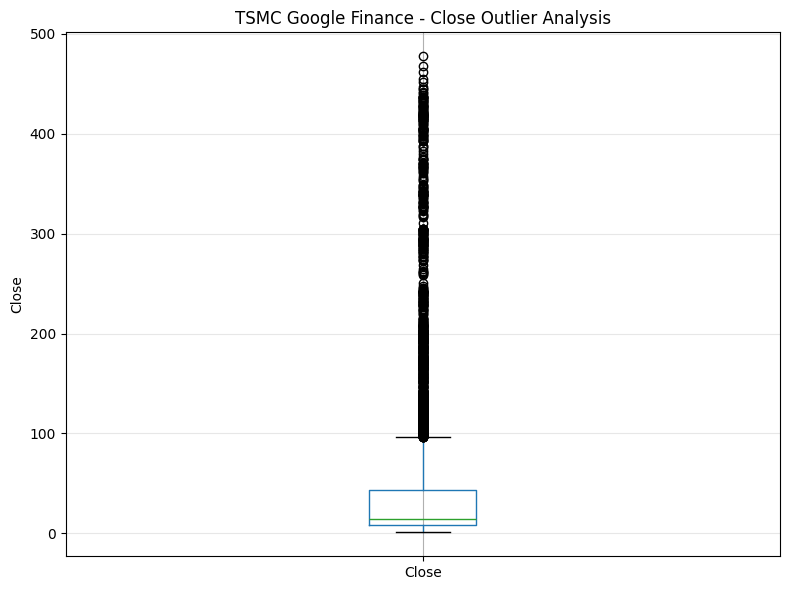

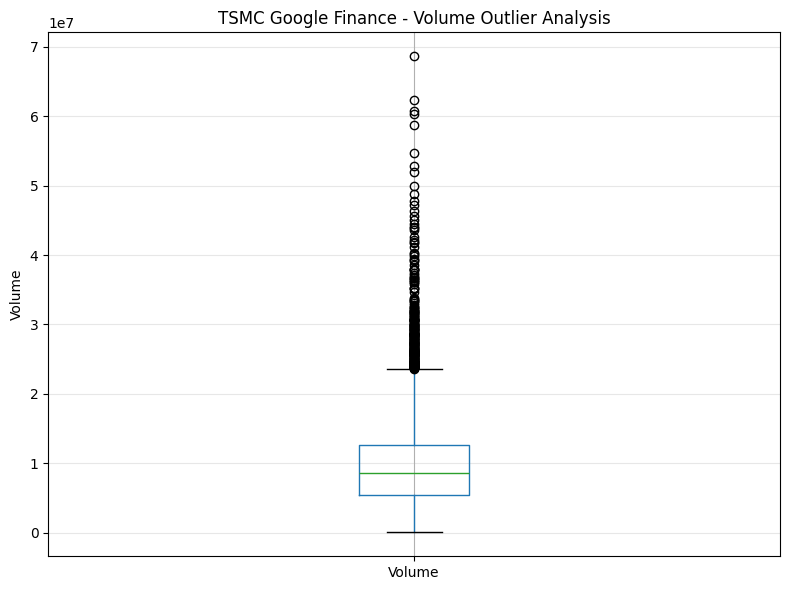

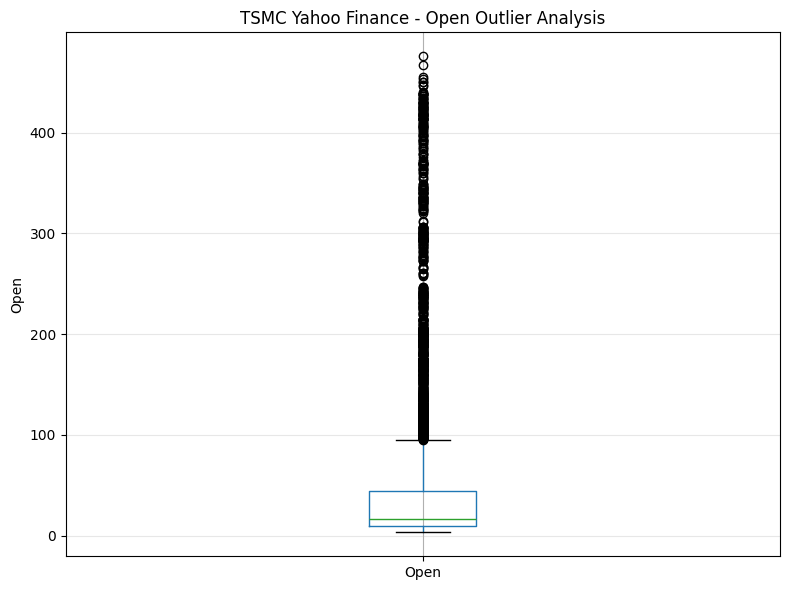

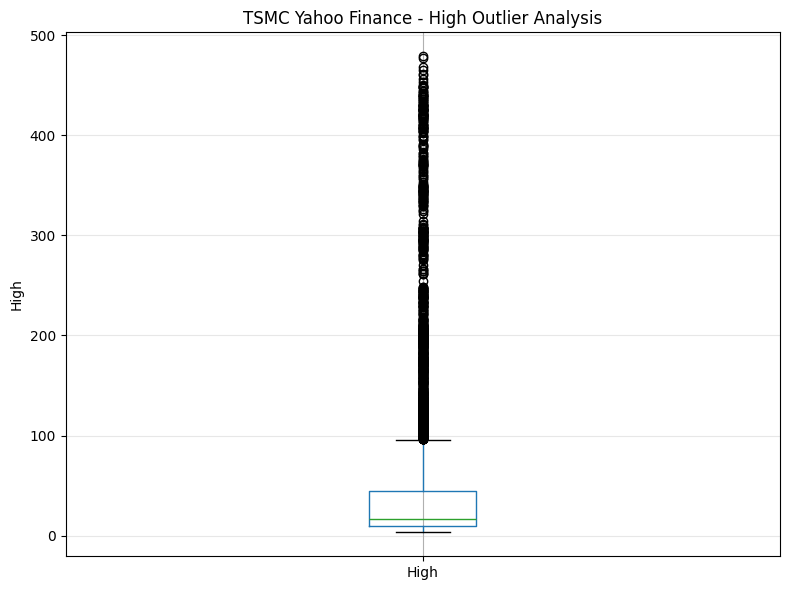

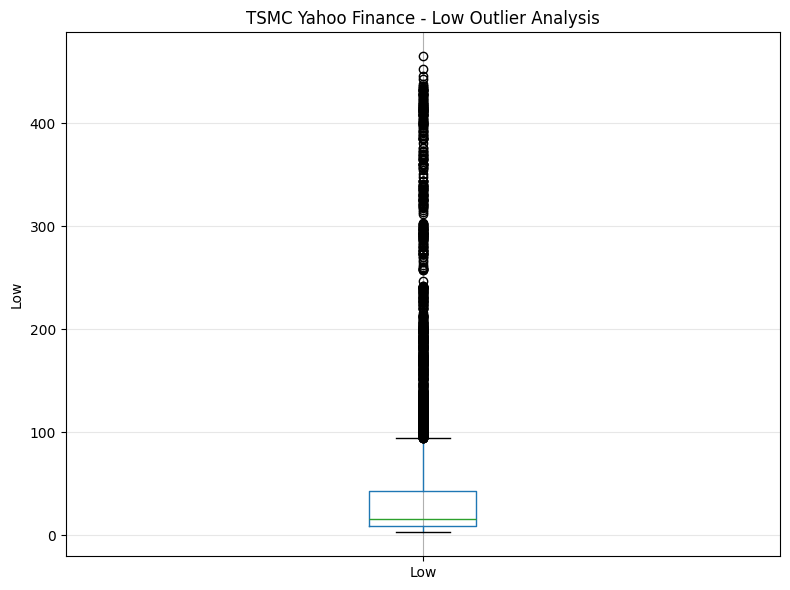

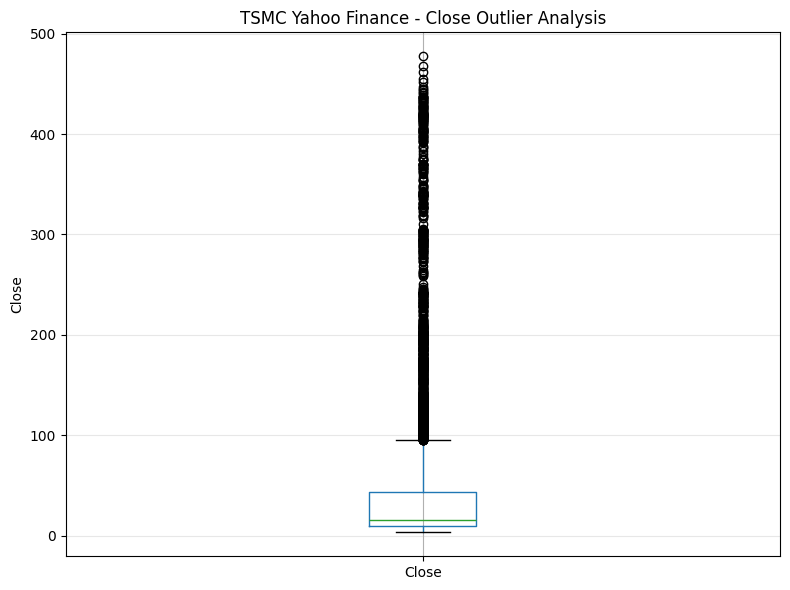

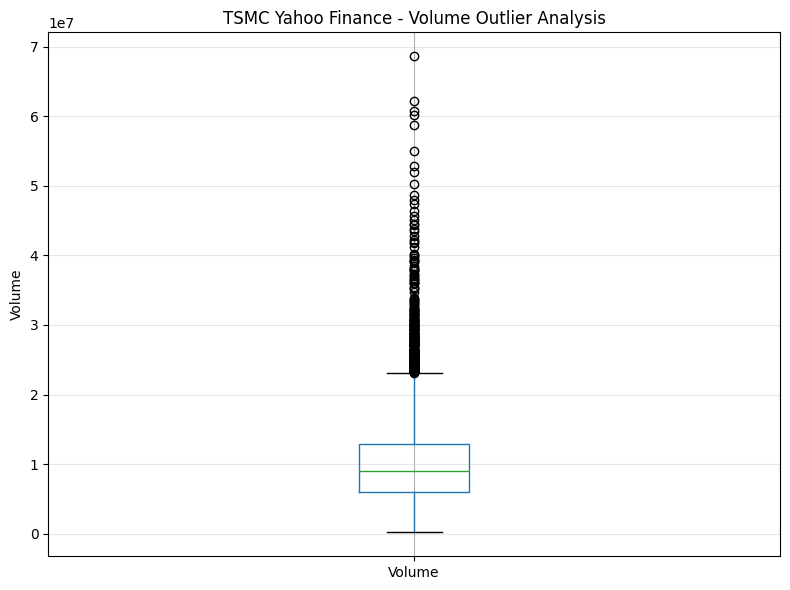

In [31]:
# ============================================
# SEPARATE BOXPLOTS FOR ALL VARIABLES
# ============================================

variables = ["Open", "High", "Low", "Close", "Volume"]


# ============================================
# GOOGLE FINANCE
# ============================================

for variable in variables:

    plt.figure(figsize=(8, 6))

    google_analysis[[variable]].boxplot()

    plt.title(
        f"TSMC Google Finance - {variable} Outlier Analysis"
    )

    plt.ylabel(variable)

    plt.grid(
        True,
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ============================================
# YAHOO FINANCE
# ============================================

for variable in variables:

    plt.figure(figsize=(8, 6))

    yahoo_analysis[[variable]].boxplot()

    plt.title(
        f"TSMC Yahoo Finance - {variable} Outlier Analysis"
    )

    plt.ylabel(variable)

    plt.grid(
        True,
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

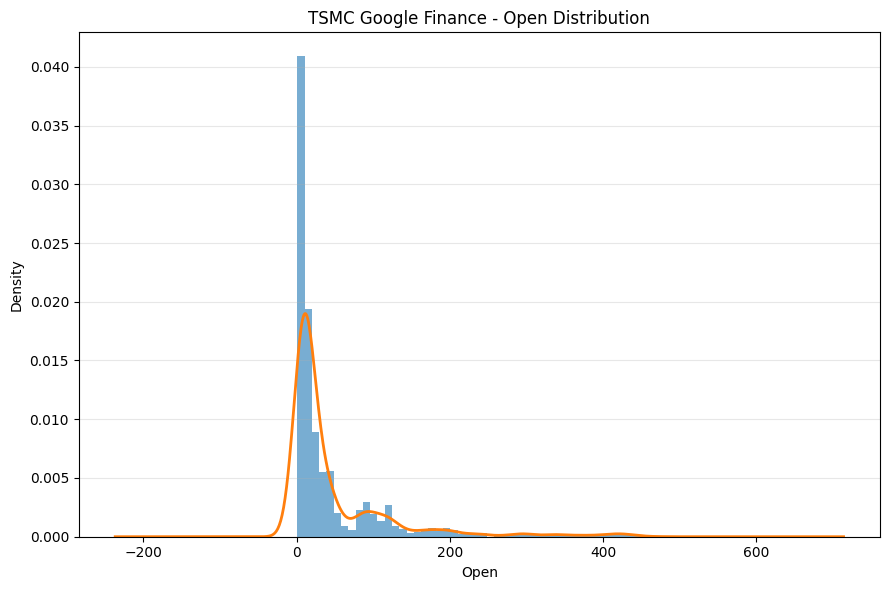

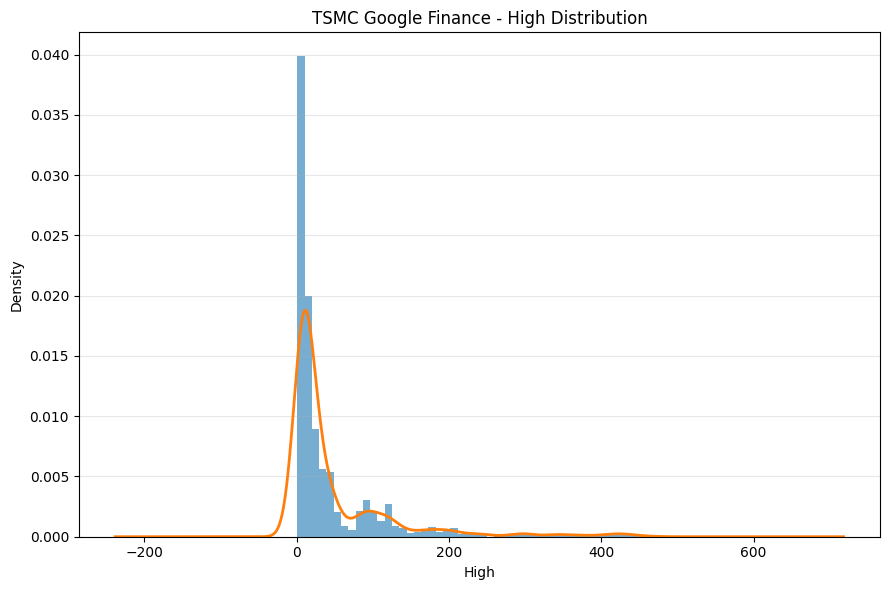

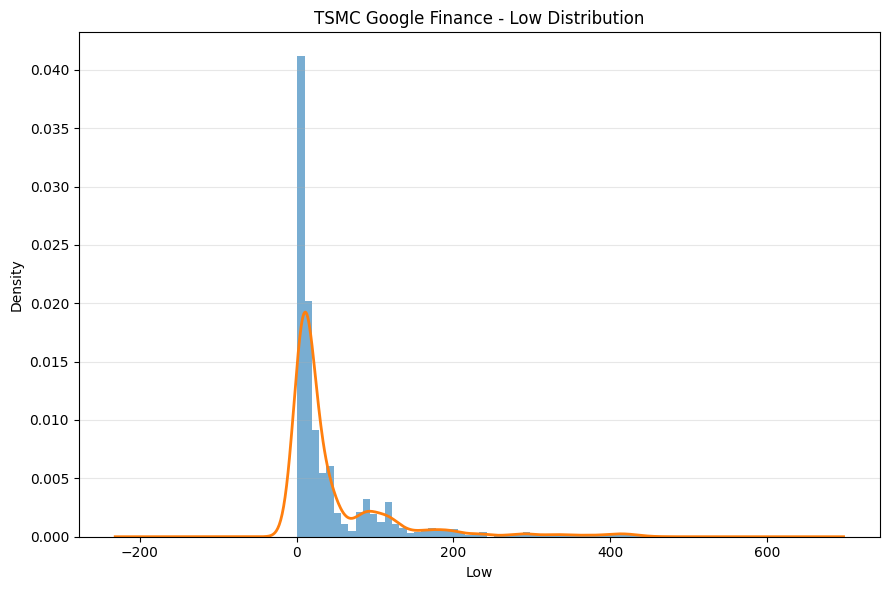

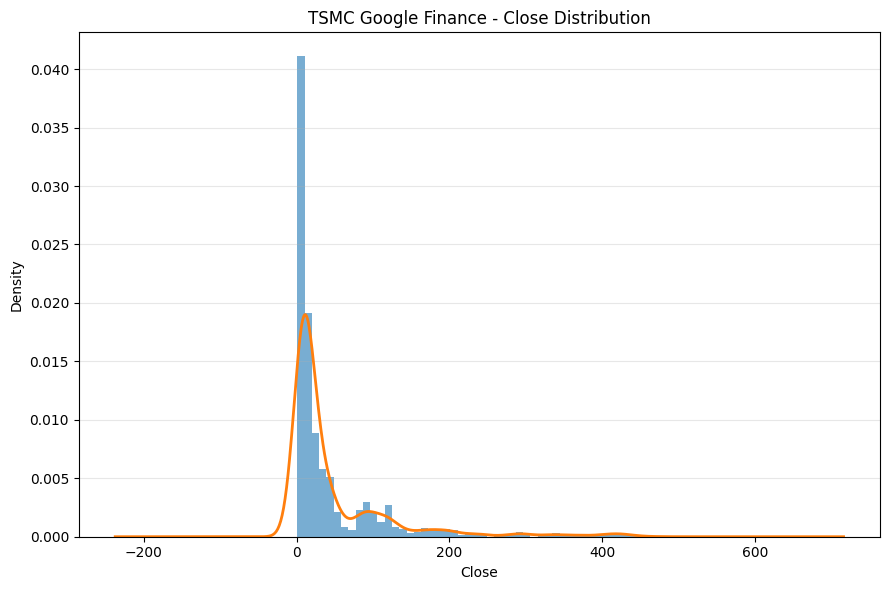

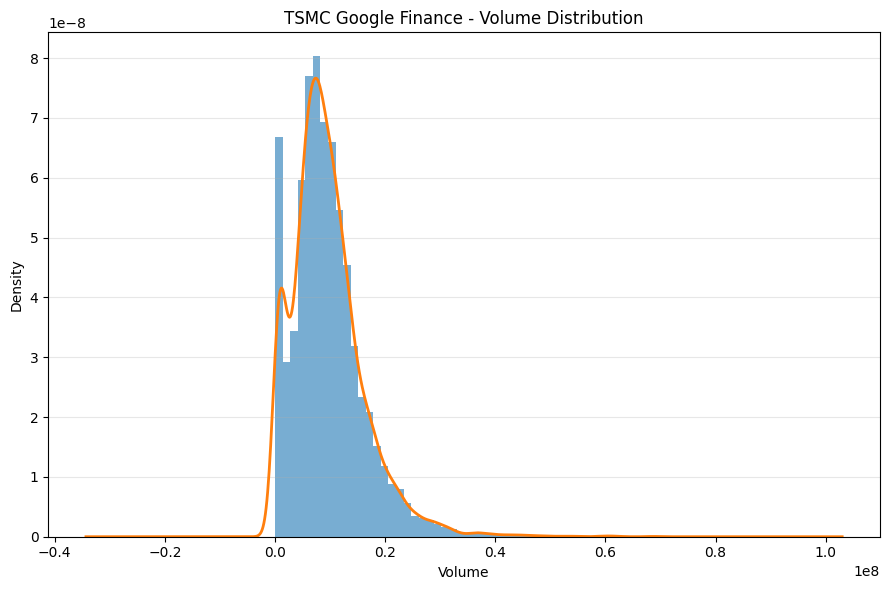

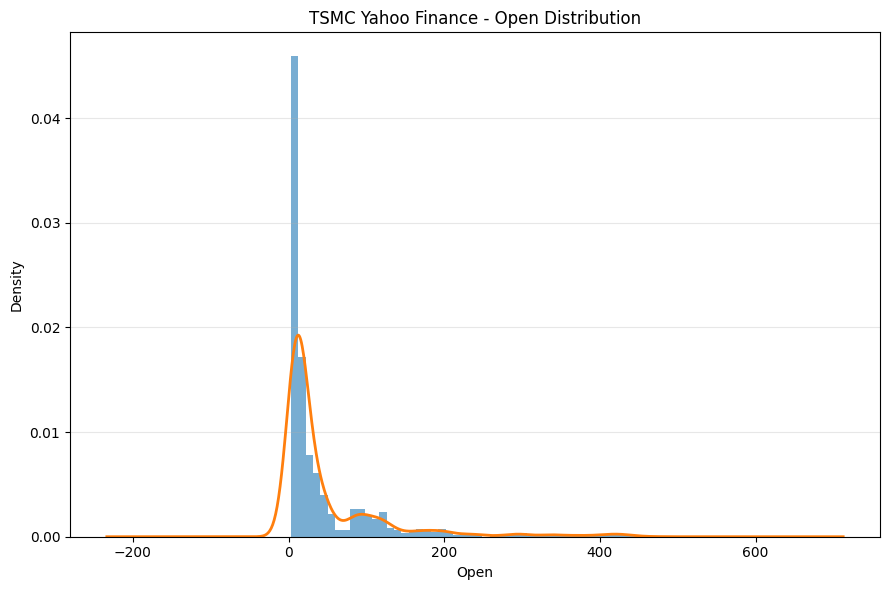

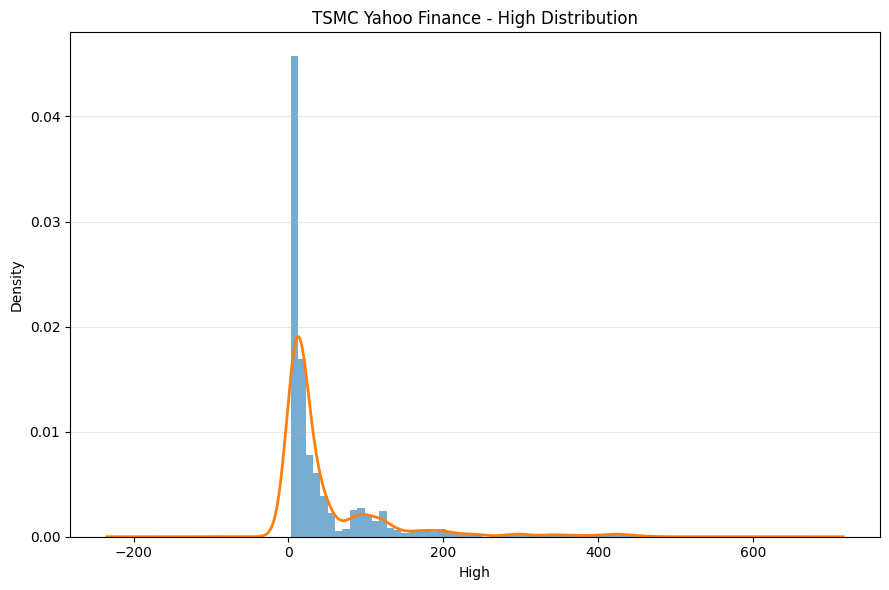

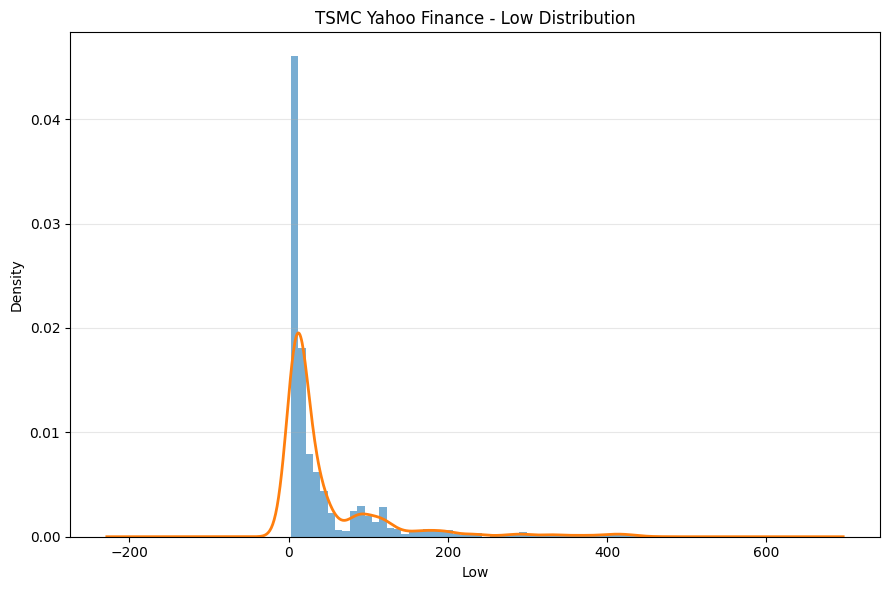

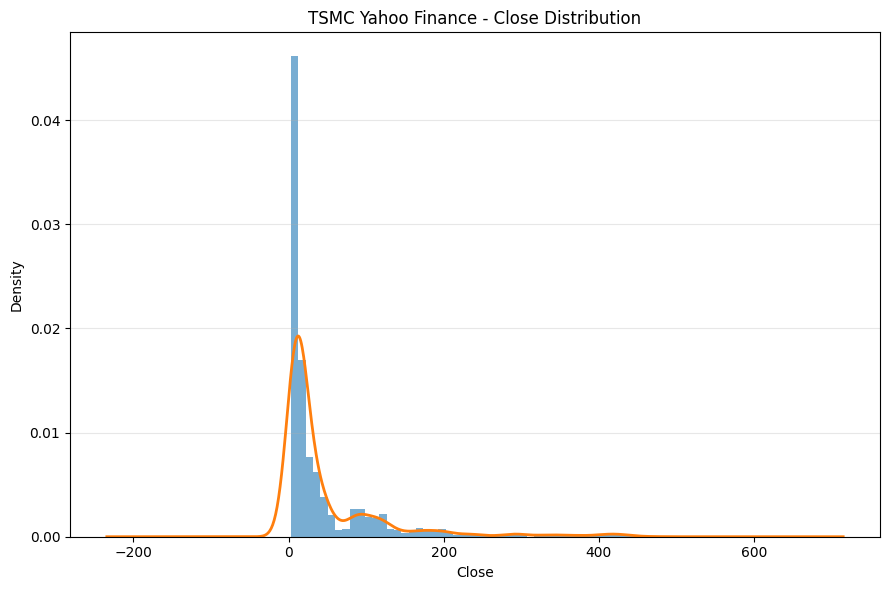

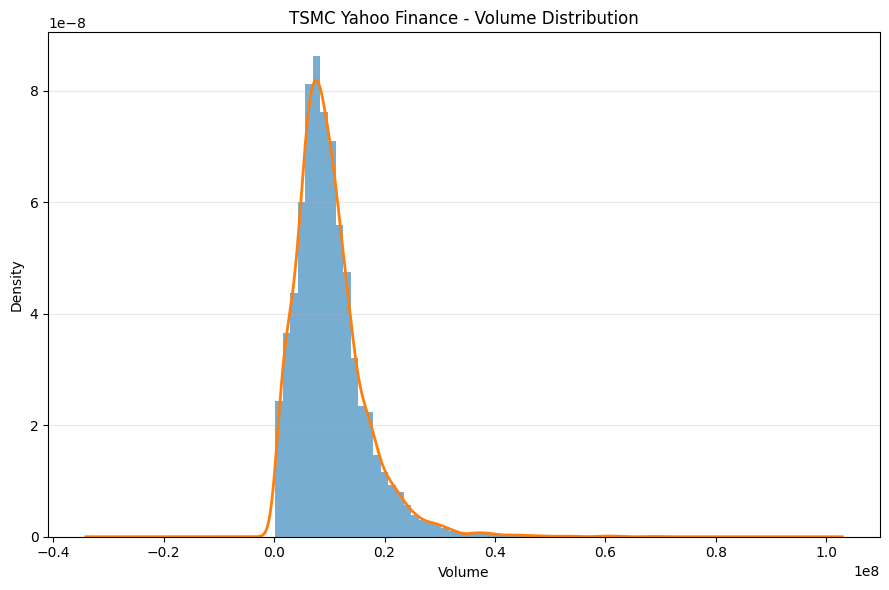

In [ ]:
# DISTRIBUTION PLOTS — ALL VARIABLES

variables = ["Open", "High", "Low", "Close", "Volume"]

# ============================================
# GOOGLE FINANCE
# ============================================

for variable in variables:
    plt.figure(figsize=(9, 6))
    google_analysis[variable].plot(kind="hist",bins=50,density=True,alpha=0.6)
    google_analysis[variable].plot(kind="kde",linewidth=2)
    plt.title(f"TSMC Google Finance - {variable} Distribution")
    plt.xlabel(variable)
    plt.ylabel("Density")
    plt.grid(True,axis="y",alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================
# YAHOO FINANCE
# ============================================

for variable in variables:
    plt.figure(figsize=(9, 6))
    yahoo_analysis[variable].plot(kind="hist",bins=50,density=True,alpha=0.6)
    yahoo_analysis[variable].plot(kind="kde",linewidth=2)
    plt.title(f"TSMC Yahoo Finance - {variable} Distribution")
    plt.xlabel(variable)
    plt.ylabel("Density")
    plt.grid(True,axis="y",alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# TRADING DAYS / CLOSED DAYS BY YEAR

yfinance["Year"] = yfinance["Date"].dt.year
trading_days = (yfinance.groupby("Year").size().reset_index(name="Trading_Days"))

# Create calendar dates
calendar = pd.DataFrame({"Date": pd.date_range(yfinance["Date"].min(),yfinance["Date"].max(),freq="D")})
calendar["Year"] = calendar["Date"].dt.year

# Weekdays only
calendar["Is_Weekday"] = calendar["Date"].dt.dayofweek < 5
weekdays = (calendar[calendar["Is_Weekday"]].groupby("Year").size().reset_index(name="Weekdays"))

# Combine
year_analysis = pd.merge(
    weekdays,
    trading_days,
    on="Year",
    how="left"
)

# Weekdays when market did not have a trading observation
year_analysis["Closed_Weekdays"] = (
    year_analysis["Weekdays"]
    - year_analysis["Trading_Days"]
)

print(year_analysis.to_string(index=False))

# Maximum trading days
max_trading = year_analysis["Trading_Days"].max()

print(
    year_analysis[
        year_analysis["Trading_Days"] == max_trading
    ]
)
max_closed = year_analysis["Closed_Weekdays"].max()

print(
    year_analysis[
        year_analysis["Closed_Weekdays"] == max_closed
    ]
)

 Year  Weekdays  Trading_Days  Closed_Weekdays
 1997        60            58                2
 1998       261           252                9
 1999       261           252                9
 2000       260           252                8
 2001       261           248               13
 2002       261           252                9
 2003       261           252                9
 2004       262           252               10
 2005       260           252                8
 2006       260           251                9
 2007       261           251               10
 2008       262           253                9
 2009       261           252                9
 2010       261           252                9
 2011       260           252                8
 2012       261           250               11
 2013       261           252                9
 2014       261           252                9
 2015       261           252                9
 2016       261           252                9
 2017       2